In [9]:
import finesse
import matplotlib.pyplot as plt
import importlib
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import functions
importlib.reload(functions)
from functions import *
finesse.configure(plotting=True)

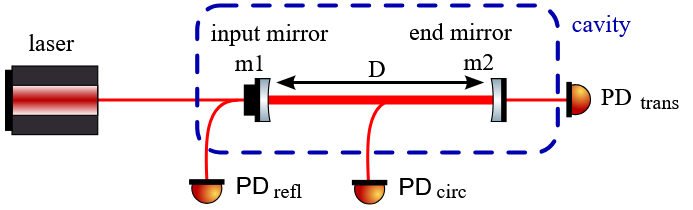

In [10]:
Lambda_0 = 24.701e-6  # Poling period of the crystal in meters
L = 405*Lambda_0
def rayleigh_length(w0, wavelength):
    '''
    Finds the rayleigh length of a beam given the beam waist and wavelength.
    Parameters:
    w0: beam waist (in meters)
    wavelength: wavelength of the beam (in meters)
    Returns:
    Rayleigh length (in meters)
    '''
    return np.pi * w0**2 / wavelength


In [11]:
#Plotting refractive index as a function of wavelength
#Parameters for the Sellmeier
A = 2.12725
B = 1.18431
C = 5.14852e-2
D = 0.6603
E = 100.00507
F = 9.68956e-3
#These experimental parameters are taken from "K. Fradkin, A. Arie, A. Skliar, and G. Rosenman"
wavelengths = np.array([1550,775]) #Wavelengths in nm
temperature = 300  # Temperature in Kelvin
a1_list = np.array([9.9587, 9.9228, -8.9603, 4.1010])*1e-6  # Experimental values taken from S. Emanueli and A. Arie
a2_list = np.array([-1.1882 ,10.459, -9.8136, 3.1481])*1e-8  # Experimental values taken from S. Emanueli and A. Arie
n_values = refractive_index_total(temperature, A, B, C, D, E, F, a1_list, a2_list, wavelengths)

In [12]:
# --- Intracavity Crystal Optimization ---
# To optimize the waist at the crystal, we must change the CAVITY geometry (m1, m2 curvatures),
# not the input lens. The input lens is for mode-matching only.

# Parameters
L_crystal = 405 * Lambda_0  # Crystal length (~10mm)
n_crystal = 1.83  # Refractive index (e.g., PPKTP @ 1064nm approx)
optical_length_approx = L_crystal*2  # Total cavity length in meters (adjust as needed)

# We place the crystal in the center of the cavity
d_air = 0 # 0 for ideal cavity

# Range of mirror curvatures to scan
# One curvature is flat and the 100% reflective curvature has a 10mm radius of curvature, so we scan around that.
radii_of_curvature = [0.1] # 10 mm

results_cavity = []

for Rc in radii_of_curvature:
    # 1. Build Model with Crystal inside
    kat_cav = finesse.Model()
    kat_cav.parse(
        f"""
        # Laser (Source)
        l L0 P=1
        s s0 L0.p1 m1.p1 L=0 # Direct coupling for eigenmode calculation

        # Cavity Mirror 1 (negative)
        m m1 R=0.99 T=0.01 Rc={-Rc} # The first mirror

        # First Air Segment
        s s_air1 m1.p2 crystal_face1.p1 L={d_air}

        # Flat Crystal Entry Face (Transparent AR coating)
        m crystal_face1 R=0 T=1
        
        # Crystal Medium
        s s_crystal crystal_face1.p2 crystal_face2.p1 L={L_crystal} nr={n_values[0]} # Use the refractive index at the fundamental wavelength

        # Crystal Exit Face (Transparent AR coating)
        m crystal_face2 R=0 T=1
        
        # Second Air Segment (Should always be zero as the crystal exitface has a curvature and reflects here.)
        s s_air2 crystal_face2.p2 m2.p1 L={0}

        # Cavity Mirror 2
        m m2 R=1 T=0 Rc={-Rc} # Symmetric
        """
    )
    
    # 2. Get the eigenmode of the cavity
    # Propagate from the crystal center (or any point inside) to get the beam parameter
    try:
        # Trace the beam through the crystal
        trace = finesse.tracing.tools.propagate_beam(
            from_node=kat_cav.m1.p2.o,
            to_node=kat_cav.m2.p1.i,
            direction='x' # Direction does not matter much for cylindrical symmetry
        )
        
        # Get waist at the center of the crystal
        # We can ask for w0 at the crystal space.
        # Since the waist should be in the center for a symmetric cavity:
        w0_center = trace.w0(at=kat_cav.s_crystal.p1.o) # Approximate at one end, or we can look for minimum
        
        # More precise: find minimum in the trace values within the crystal
        # But for symmetric cavity, waist is at center. 
        # Let's get the beam parameter q at the center.
        # easier: trace.w0 returns the parameter w0 of the beam segment flowing through the component.
        # For the crystal space 's_crystal', trace.w0(at=...) gives the waist size of that Gaussian mode.
        w0_crystal = trace.w0(at=kat_cav.s_crystal.p1.o)
        
        # Calculate Rayleigh Range inside the crystal
        # z_R = pi * w0^2 * n / lambda
        wavelength = 1550 # Assuming 1064nm, adjust if needed
        z_R = np.pi * w0_crystal**2 * n_crystal / wavelength
        
        # Focusing Parameter xi = L / (2 * z_R) (Wait, definition varies, sometimes L/b)
        # b = 2 * z_R
        # xi = L / b
        xi = L_crystal / (2 * z_R)
        
        results_cavity.append((Rc, w0_crystal, xi))
        
    except Exception as e:
        # Unstable cavity configuration
        pass

# Convert to arrays for plotting
if not results_cavity:
    print("No stable configurations found!")
else:
    results_cavity = np.array(results_cavity)
    if results_cavity.ndim == 1:
        # Handle case with only one result row, reshape to 2D
        results_cavity = results_cavity.reshape(1, -1)
        
    Rcs = results_cavity[:, 0]
    w0s = results_cavity[:, 1]
    xis = results_cavity[:, 2]

    # Plot
    fig, ax1 = plt.subplots(figsize=(8, 5))

    color = 'tab:red'
    ax1.set_xlabel('Mirror Radius of Curvature (m)')
    ax1.set_ylabel('Beam Waist $w_0$ (mm)', color=color)
    ax1.plot(Rcs, w0s * 1e3, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:blue'
    ax2.set_ylabel('Focusing Parameter $\\xi = L/2z_R$', color=color)
    ax2.plot(Rcs, xis, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.axhline(2.84, color='green', linestyle='--', label='Optimal $\\xi \\approx 2.84$')
    ax2.legend(loc='upper right')

    plt.title(f"Optimizing Cavity for Crystal Length L={L_crystal*1000:.1f}mm")
    plt.show()

No stable configurations found!


(<Figure size 576x355.968 with 2 Axes>,
 array([<Axes: ylabel='Beam size [mm]'>,
        <Axes: xlabel='Distance [m]', ylabel='Gouy phase\naccumulation [deg]'>],
       dtype=object))

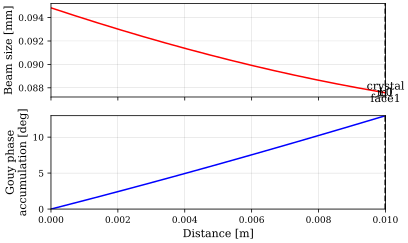

In [13]:
d_air = 0
rc1 = 0.1
rc2 = 0.1
kat_cav = finesse.Model()
kat_cav.parse(
    f"""
    # Laser (Source)
    l L0 P=1
    s s0 L0.p1 m1.p1 L=0 # Direct coupling for eigenmode calculation

    # Cavity Mirror 1 (separate component)
    m m1 R=0.99 T=0.01 Rc={-rc1}

    # First Air Segment (between Mirror 1 and Crystal)
    s s_air1 m1.p2 crystal_face1.p1 L={d_air}

    # Flat Crystal Entry Face (Transparent AR coating)
    m crystal_face1 R=0 T=1
    
    # Crystal Medium
    # Connects the flat entry face (crystal_face1) directly to the curved back mirror (m2)
    s s_crystal crystal_face1.p2 m2.p1 L={L_crystal} nr={n_values[0]} 

    # Cavity Mirror 2 (Curved back face of the crystal)
    # This component represents the HR coating on the curved surface of the crystal itself.
    # Note: R=1 (HR), Rc is the curvature of the physical surface.
    m m2 R=1 T=0 Rc={rc2} 
    """
)

# Add some curvatures to our mirrors.
kat_cav.m1.Rc = 0.1
kat_cav.m2.Rc = 0.1
# Define the cavity.
kat_cav.parse("cavity cavity1 source=m1.p2.o via=m2.p1.i priority=1")

# Plot the beam trace, starting from cavity the eigenmode.
tsy = finesse.tracing.tools.propagate_beam(
    to_node=kat_cav.L0.p1.i, from_node=kat_cav.m2.p1.o, direction="y"
)
tsy.plot()

In [14]:
def calculate_beam_waist(curve1, curve2, d_air1, L_crystal, n_vals, wavelength):
    kat_cav = finesse.Model()
    kat_cav.lambda0 = wavelength
    kat_cav.parse(
        f"""
        # Laser (Source)
        l L0 P=1
        s s0 L0.p1 m1.p1 L=0 # Direct coupling for eigenmode calculation

        # Cavity Mirror 1 (separate component)
        m m1 R=0.99 T=0.01 Rc={-curve1}

        # First Air Segment (between Mirror 1 and Crystal)
        s s_air1 m1.p2 crystal_face1.p1 L={d_air1}

        # Flat Crystal Entry Face (Transparent AR coating)
        m crystal_face1 R=0 T=1
        
        # Crystal Medium
        # Connects the flat entry face (crystal_face1) directly to the curved back mirror (m2)
        s s_crystal crystal_face1.p2 m2.p1 L={L_crystal} nr={n_vals[0]} 

        # Cavity Mirror 2 (Curved back face of the crystal)
        # This component represents the HR coating on the curved surface of the crystal itself.
        # Note: R=1 (HR), Rc is the curvature of the physical surface.
        m m2 R=1 T=0 Rc={curve2} 
        """
    )
    
    kat_cav.parse("cavity cavity1 source=m1.p2.o via=m2.p1.i priority=1")
    
    try:
        trace = finesse.tracing.tools.propagate_beam(
            from_node=kat_cav.m1.p2.o,
            to_node=kat_cav.m2.p1.i,
            direction='x'
        )
        return trace.w0(at=kat_cav.s_crystal.p1.o)
    except Exception:
        return None

beam_waists = []
# Example single run
for c1 in [0.1]: 
    for c2 in [0.1]: 
        w0 = calculate_beam_waist(c1, c2, d_air, L_crystal, n_values, Lambda_0)
        beam_waists.append(w0)

def focusing_parameter(L, w0, wavelength):
    z_R = np.pi * w0**2 / wavelength
    xi = L / (2 * z_R)
    return xi

# Sweep
curve_sweep = np.linspace(0.05, 0.5, 100) # 5 mm to 15 mm (Edit: range seems small for meters, keeping user values)
xi_vals = []
w_0_vals = []

for curve in curve_sweep:
    w0 = calculate_beam_waist(curve, curve, d_air, L_crystal, n_values, Lambda_0)
    if w0 is None:
        xi_vals.append(np.nan)
        w_0_vals.append(np.nan)
    else:
        xi = focusing_parameter(L_crystal, w0, wavelength = wavelengths[0])
        xi_vals.append(xi)
        w_0_vals.append(w0)

w_0_vals = np.array(w_0_vals)
xi_vals = np.array(xi_vals)

c:\Users\eskil\miniconda3\envs\simulation\Lib\site-packages\finesse\model.py:2136: CavityUnstableWarning: cavity 'cavity1' added to the model is unstable
  warn(


Optimal Focusing Parameter xi: 0.520 (Target: 2.84)
Required Mirror Curvature:     20.00 mm
Resulting Beam Waist w0:       51.11 um


C:\Users\eskil\AppData\Local\Temp\ipykernel_17204\1735539086.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc ='upper left')


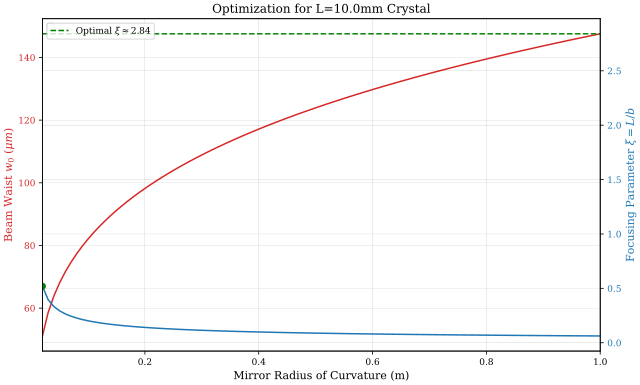

In [15]:
# 1. Use the correct Optical Wavelength (e.g., 1550 nm)
laser_wavelength = wavelengths[0] * 1e-9  # Convert nm to meters if wavelengths is in nm
# laser_wavelength = 1550e-9 # Or explicit value

# 2. Corrected focusing parameter function (Focusing inside the crystal)
def focusing_parameter(L, w0, wavelength, n):
    # Rayleigh range inside a medium of index n
    z_R = (np.pi * w0**2 * n) / wavelength
    xi = L / (2 * z_R)
    return xi

# Sweep
beam_waists = []
xi_vals = []
w_0_vals = []
curve_sweep = np.linspace(0.01, 1, 100) # Range of mirror radii (m)

for curve in curve_sweep:
    # PASS laser_wavelength, NOT Lambda_0
    w0 = calculate_beam_waist(curve, curve, d_air, L_crystal, n_values, laser_wavelength)
    
    if w0 is None:
        xi_vals.append(np.nan)
        w_0_vals.append(np.nan)
    else:
        # Pass refractive index n to the calculation
        xi = focusing_parameter(L_crystal, w0, laser_wavelength, n_values[0])
        xi_vals.append(xi)
        w_0_vals.append(w0)

w_0_vals = np.array(w_0_vals)
xi_vals = np.array(xi_vals)

# --- Find the Optimal Parameters ---
# Find index where xi is closest to 2.84
optimal_idx = np.nanargmin(np.abs(xi_vals - 2.84))
optimal_curvature = curve_sweep[optimal_idx]
optimal_waist = w_0_vals[optimal_idx]

print(f"Optimal Focusing Parameter xi: {xi_vals[optimal_idx]:.3f} (Target: 2.84)")
print(f"Required Mirror Curvature:     {optimal_curvature*1000:.2f} mm")
print(f"Resulting Beam Waist w0:       {optimal_waist*1e6:.2f} um")

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:red'
ax1.set_xlabel('Mirror Radius of Curvature (m)')
ax1.set_ylabel('Beam Waist $w_0$ ($\mu m$)', color=color)
ax1.plot(curve_sweep, w_0_vals * 1e6, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel(r'Focusing Parameter $\xi = L/b$', color=color)
ax2.plot(curve_sweep, xi_vals, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Mark the optimum
ax2.axhline(2.84, color='green', linestyle='--', label='Optimal $\\xi \\approx 2.84$')
ax2.plot(optimal_curvature, xi_vals[optimal_idx], 'go') 
ax2.legend(loc='upper right')
ax1.legend(loc ='upper left')
ax2.legend(loc='upper left')

plt.title(f"Optimization for L={L_crystal*1000:.1f}mm Crystal")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
#Calculate the second harmonnic generation effeciany as a function of the beam waist
